# Import blast results and import as a network

- look at Phaeocystis hits specifically

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import igraph as ig

import sys

import numpy as np
from Bio.Blast import NCBIXML   #to parse XML files


import upsetplot

In [10]:
#From fasta file create pandas df of ASV and sequence
def from_fasta_to_df(file):
    print(file)
    with open(file) as f:
        Ids=[]
        seqs =[]
        for strline in f:
            if strline[0]=='>':
                Ids.append(strline[1:].strip())
            else:
                seqs.append(strline.strip())
    print('Number of Ids:',len(Ids))
    print('Number of Seqs:',len(seqs))
    seq_dict = dict(zip(Ids, seqs))
    #make pandas df
    df= pd.DataFrame.from_dict(seq_dict,orient='index', columns=['sequence'])
    return df

In [2]:
# asv file
file = '../data/merged_original_taxonomy/GLOMICON_asv_merged.csv'
df = pd.read_csv(file)
df.set_index('ASV', inplace=True)
asv_all = df.copy()
asv_all.head()

,Davenport_02_0008,Davenport_06_0008,Davenport_11_0008,Davenport_15_0008,Davenport_19_0008,Framstrait_01_0008,Framstrait_05_0008,Framstrait_09_0008,Framstrait_13_0008,Framstrait_17_0008,...,E-G30-eMockB-18,E-G29-eMockA-11,E-G32-bMock2,G11r-DAL30,E-G35-bMock22,G20r-ROS12,E-G31-eMockB-20,E-G34-bMock20,E-G1-AWI11,E-G33-bMock9
ASV,,,,,,,,,,,,,,,,,,,,,
ASV_1,0,0,0,0,0,0,0,0,0,0,...,1712.0,1266.0,33675.0,124.0,34286.0,4.0,1383.0,56835.0,360.0,34134.0
ASV_2,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ASV_3,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ASV_4,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ASV_5,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [41]:
# taxa file
file = '../data/merged_original_taxonomy/GLOMICON_taxa_merged.csv'
df = pd.read_csv(file)
df.set_index('ASV', inplace=True)
taxa_all = df.copy()
taxa_all.head()

,domain,kingdom,supergroup,division,subdivision,class,order,family,genus,species
ASV,,,,,,,,,,
ASV_1,Eukaryota,unassigned,unassigned,Prymnesiophyceae,unassigned,Prymnesiophyceae,Prymnesiophyceae,Prymnesiophyceae,Phaeocystis,Phaeocystis_pouchetii
ASV_2,Eukaryota,unassigned,unassigned,Bacillariophyta,unassigned,Coscinodiscophyceae,Thalassiosirales,Thalassiosiraceae,Thalassiosira,unassigned
ASV_3,Eukaryota,unassigned,unassigned,Bacillariophyta,unassigned,Coscinodiscophyceae,Melosirales,Melosiraceae,Melosira,unassigned
ASV_4,Eukaryota,unassigned,unassigned,Bacillariophyta,unassigned,Bacillariophyceae,Bacillariales,Bacillariaceae,Pseudo-nitzschia,unassigned
ASV_5,Eukaryota,unassigned,unassigned,unassigned,unassigned,Dinophyceae,Thoracosphaerales,Thoracosphaeraceae,Ensiculifera,Ensiculifera_imariensis


In [3]:
# metadata file
file = '../data/merged_original_taxonomy/GLOMICON_meta_merged.csv'
df = pd.read_csv(file)
df.set_index('sample_name', inplace=True)
meta_all = df.copy()
meta_all.head()

,Analyzing_Institute,Collecting_Institute,site
sample_name,,,
Davenport_02_0008,AWI,MBARI,Monterey Bay
Davenport_06_0008,AWI,MBARI,Monterey Bay
Davenport_11_0008,AWI,MBARI,Monterey Bay
Davenport_15_0008,AWI,MBARI,Monterey Bay
Davenport_19_0008,AWI,MBARI,Monterey Bay


In [4]:
# csv file of every sequence in project - ASV IDs may shift if upstream processing is rerun
file = '../data/merged_original_taxonomy/GLOMICON_seq_merged.csv'
df = pd.read_csv(file)
df.set_index('ASV', inplace=True)
seq_all = df.copy()
seq_all

,sequence,Analyzing_Institute
ASV,,
ASV_1,CAATAGCGTATATTAAAGTTGTTGCAGTTAAAAAGCTCGTAGTCGG...,UDAL
ASV_2,GCACCTACCGATTGAATGGTCCGGTGAAGACTCGGGATTGTGGTCT...,MBARI
ASV_3,GCACCTACCGATTGAATGGTCCGGTGAGGCCTCGGGATCGTGGCGA...,MBARI
ASV_4,GCACCTACCGATTGAATGGTCCGGTGAAGCCTCGGGATTGTGGTTG...,MBARI
ASV_5,GCTCCTACCGATTGAGTGATCCGGTGAATAATTCGGACTGCAGCAG...,MBARI
...,...,...
ASV_14543,TAGCGTATATTAATGTTGTTGCAGTTAAAAAGCTCGTAGTTGGATT...,AWI
ASV_14544,TAGCGTATACTAAAGTTGTTGCAGTTAAAAAGCTCGTAGTTGAATT...,AWI
ASV_14545,TAGCGTATACTAAAGTTGTTGCAGTTAAAAAGCTCGTAGTTGAATT...,AWI


In [53]:
seq_all.iloc[28]

sequence               GCTCCTACCGATTGAATGATCCGGTGAATAATTTGGACTGTAGCAA...
Analyzing_Institute                                                MBARI
Name: ASV_29, dtype: object

In [32]:
# fasta file used in blast analysis:
file = '/Users/kpitz/github/GLOMICON/intercomparison/Merged_Datasets/data/GLOMICON_merged.fasta'
df = from_fasta_to_df(file)
uniq_seqs = df.copy()
uniq_seqs

/Users/kpitz/github/GLOMICON/intercomparison/Merged_Datasets/data/GLOMICON_merged.fasta
Number of Ids: 21323
Number of Seqs: 21323


,sequence
ASV_1|UDAL,CAATAGCGTATATTAAAGTTGTTGCAGTTAAAAAGCTCGTAGTCGG...
ASV_2|MBARI,GCACCTACCGATTGAATGGTCCGGTGAAGACTCGGGATTGTGGTCT...
ASV_3|PARADA,TTCCAGCTCCAATAGCGTATATTAAAGTTGTTGCAGTTAAAAAGCT...
ASV_4|MBARI,GCACCTACCGATTGAATGGTCCGGTGAGGCCTCGGGATCGTGGCGA...
ASV_5|MBARI,GCACCTACCGATTGAATGGTCCGGTGAAGCCTCGGGATTGTGGTTG...
...,...
ASV_21319|AWI,TAGCGTATATTAAAGTTGTTGCGGTTAAAAAGCTCGTAGTTGGATT...
ASV_21320|AWI,TAGCGTATATTAATGTTGTTGCAGTTAAAAAGCTCGTAGTTGGATT...
ASV_21321|AWI,TAGCGTATACTAAAGTTGTTGCAGTTAAAAAGCTCGTAGTTGAATT...
ASV_21322|AWI,TAGCGTATACTAAAGTTGTTGCAGTTAAAAAGCTCGTAGTTGAATT...


### Parse Blastn XML file

In [6]:
# blastn xml file:
blast_file = '/Users/kpitz/github/GLOMICON/intercomparison/Merged_Datasets/network/Phaeocystales_db/Phaeo_hits.xml'


In [7]:
# Only save top 2% of bitscore hits to query
print('Blast XML file: ', blast_file)
hit_dict ={}  #Dictionary to store hits
result_handle =open(blast_file)
#parse blast records
blast_records= NCBIXML.parse(result_handle)
for blast_record in blast_records:
    query = blast_record.query
    hit_ID=0 #hit counter
    for alignment in blast_record.alignments:
        hit_ID+=1
        key = (query, hit_ID)
        hsp = alignment.hsps[0] #only look at top hsp per alignment to genbank sequence
        #set limits on evalue and bitscore and % Identity
        per_iden = hsp.identities/float(hsp.align_length)
        per_iden = (per_iden *100)
        per_iden = round(per_iden, 2)
        evalue = hsp.expect
        bitscore = int(hsp.score)
        # set bitscore limit for hits, within top 2%
        if hit_ID ==1:
            top_bitscore = bitscore
            min_bitscore = top_bitscore - (top_bitscore*.02)
        if bitscore < min_bitscore:
            #continue to next alignment if bitscore too low
            continue
        #alignment length
        align_len = hsp.align_length
        # save results to dictionary
        value = (evalue, bitscore, per_iden, alignment.hit_def, align_len)
        hit_dict[key]=value
print ('Done parsing ', blast_file)

Blast XML file:  /Users/kpitz/github/GLOMICON/intercomparison/Merged_Datasets/network/Phaeocystales_db/Phaeo_hits.xml
Done parsing  /Users/kpitz/github/GLOMICON/intercomparison/Merged_Datasets/network/Phaeocystales_db/Phaeo_hits.xml


In [14]:
#Save Blast Results to file
df = pd.DataFrame(hit_dict)
df=df.T
df.columns = ['eval','bitscore', '%ID', 'hit_def', 'align_len']
df.reset_index(inplace=True)
df = df.rename(columns={'level_0': 'ASV', 'level_1': 'Hit_number'})
blastn = df.copy()
df

,ASV,Hit_number,eval,bitscore,%ID,hit_def,align_len
0,ASV_1|UDAL,1,0.0,350,100.0,HQ869452.1.911_U|Haptista|Haptophyta|Prymnesio...,350
1,ASV_1|UDAL,2,0.0,350,100.0,KC488454.1.1667_U|Haptista|Haptophyta|Prymnesi...,350
2,ASV_1|UDAL,3,0.0,350,100.0,HM561166.1.964_U|Haptista|Haptophyta|Prymnesio...,350
3,ASV_1|UDAL,4,0.0,350,100.0,HM561167.1.839_U|Haptista|Haptophyta|Prymnesio...,350
4,ASV_1|UDAL,5,0.0,350,100.0,HM561164.1.955_U|Haptista|Haptophyta|Prymnesio...,350
...,...,...,...,...,...,...,...
254465,ASV_21318|AWI,4,0.0,93,75.77,JX660990.1.1627_U|Haptista|Haptophyta|Prymnesi...,388
254466,ASV_21319|AWI,1,0.0,47,74.78,JX188372.1.1762_U|Haptista|Haptophyta|Prymnesi...,230
254467,ASV_21321|AWI,1,0.0,88,80.09,EU561892.1.976_U|Haptista|Haptophyta|Prymnesio...,226
254468,ASV_21322|AWI,1,0.0,88,80.09,EU561892.1.976_U|Haptista|Haptophyta|Prymnesio...,226


In [12]:
#Save Blast Results to file
df = pd.DataFrame(hit_dict)
df=df.T
df.columns = ['eval','bitscore', '%ID', 'hit_def', 'align_len']
df.reset_index(inplace=True)
df = df.rename(columns={'level_0': 'ASV', 'level_1': 'Hit_number'})
#df.set_index('ASV', inplace=True)
#df = pd.concat([df, uniq_seqs], axis=1 )


df = df.join(uniq_seqs, on='ASV')
df = df.rename(columns={'sequence':'sequence_query'})
df = df.join(uniq_seqs, on='hit_def')
df = df.rename(columns={'sequence':'sequence_hit'})
df = df.drop(['ASV', 'hit_def'], axis=1)
df.set_index('sequence_query', inplace=True)
all_hits = df.copy()
# save results to file:
file = '/Users/kpitz/github/GLOMICON/intercomparison/Merged_Datasets/network/Phaeocystales_db/Phaeo_hits.csv'
df.to_csv(file)
df

,Hit_number,eval,bitscore,%ID,align_len,sequence_hit
sequence_query,,,,,,
CAATAGCGTATATTAAAGTTGTTGCAGTTAAAAAGCTCGTAGTCGGATTTCGGGTCGGGCCGAGCGGTCTGCCGATGGGTATGCACTGTTTGGCGCGGCCTTCTTTCCGGAGACCGCGGCTACTCTTAACTGAGCGGGCGTGGGAGACGGATCGTTTACTTTGAAAAAATCAGAGTGTTTCTAGCAGGCAGCTCGCTCTTGCATAGGTTAGCATGGGATAATTTAATAGGACTCTGGTGCTATTTTGTTGGTTTCGAACACCGGAGTAATGATTAAAAGGGGCAGTCAGGGGCACTCGTATTCCGTCGAGAGAGGTGAAATTCTCAGACCAATGGAAGACGAACCACTGC,1,0.0,350,100.0,350,NaN
CAATAGCGTATATTAAAGTTGTTGCAGTTAAAAAGCTCGTAGTCGGATTTCGGGTCGGGCCGAGCGGTCTGCCGATGGGTATGCACTGTTTGGCGCGGCCTTCTTTCCGGAGACCGCGGCTACTCTTAACTGAGCGGGCGTGGGAGACGGATCGTTTACTTTGAAAAAATCAGAGTGTTTCTAGCAGGCAGCTCGCTCTTGCATAGGTTAGCATGGGATAATTTAATAGGACTCTGGTGCTATTTTGTTGGTTTCGAACACCGGAGTAATGATTAAAAGGGGCAGTCAGGGGCACTCGTATTCCGTCGAGAGAGGTGAAATTCTCAGACCAATGGAAGACGAACCACTGC,2,0.0,350,100.0,350,NaN
CAATAGCGTATATTAAAGTTGTTGCAGTTAAAAAGCTCGTAGTCGGATTTCGGGTCGGGCCGAGCGGTCTGCCGATGGGTATGCACTGTTTGGCGCGGCCTTCTTTCCGGAGACCGCGGCTACTCTTAACTGAGCGGGCGTGGGAGACGGATCGTTTACTTTGAAAAAATCAGAGTGTTTCTAGCAGGCAGCTCGCTCTTGCATAGGTTAGCATGGGATAATTTAATAGGACTCTGGTGCTATTTTGTTGGTTTCGAACACCGGAGTAATGATTAAAAGGGGCAGTCAGGGGCACTCGTATTCCGTCGAGAGAGGTGAAATTCTCAGACCAATGGAAGACGAACCACTGC,3,0.0,350,100.0,350,NaN
CAATAGCGTATATTAAAGTTGTTGCAGTTAAAAAGCTCGTAGTCGGATTTCGGGTCGGGCCGAGCGGTCTGCCGATGGGTATGCACTGTTTGGCGCGGCCTTCTTTCCGGAGACCGCGGCTACTCTTAACTGAGCGGGCGTGGGAGACGGATCGTTTACTTTGAAAAAATCAGAGTGTTTCTAGCAGGCAGCTCGCTCTTGCATAGGTTAGCATGGGATAATTTAATAGGACTCTGGTGCTATTTTGTTGGTTTCGAACACCGGAGTAATGATTAAAAGGGGCAGTCAGGGGCACTCGTATTCCGTCGAGAGAGGTGAAATTCTCAGACCAATGGAAGACGAACCACTGC,4,0.0,350,100.0,350,NaN
CAATAGCGTATATTAAAGTTGTTGCAGTTAAAAAGCTCGTAGTCGGATTTCGGGTCGGGCCGAGCGGTCTGCCGATGGGTATGCACTGTTTGGCGCGGCCTTCTTTCCGGAGACCGCGGCTACTCTTAACTGAGCGGGCGTGGGAGACGGATCGTTTACTTTGAAAAAATCAGAGTGTTTCTAGCAGGCAGCTCGCTCTTGCATAGGTTAGCATGGGATAATTTAATAGGACTCTGGTGCTATTTTGTTGGTTTCGAACACCGGAGTAATGATTAAAAGGGGCAGTCAGGGGCACTCGTATTCCGTCGAGAGAGGTGAAATTCTCAGACCAATGGAAGACGAACCACTGC,5,0.0,350,100.0,350,NaN
...,...,...,...,...,...,...
TAGCGTATATTAAAGTTGTTGCAGTTAAAAAGCTCGTAGTTGGATTTCTGGACGAAGTTGTCGGTCCGCCGCTGTGCGGTGTGTACTTGATCAACCTTCGTTCATCCTTGCAGGGAAGCGCATTTCGGCATTCAGTTGTCGGGGCGGGGAACTGCATCTTTTACTGTGAAAAAATTAGAGTGTTTAAAGCAGGCATTTTGCTGTGAATACATTAGCATGGAATAATAACATAGGACCTCGGTTCTATTTTGTTGGTTGGAGACCAAGGTAATGATTAATAGGGACAGTTGGGGGTATTCATATTTAATTGTCAGAGGTGAAATTCTTGGATTTATGAAAGATGAACTCATGCGAAAGCATTTACCAAGGATGTTTTCATTA,4,0.0,93,75.77,388,NaN
TAGCGTATATTAAAGTTGTTGCGGTTAAAAAGCTCGTAGTTGGATTTCTGTCGAAGACGGTCGGTCCGCTCTATGAGCGAGTATCTGATTCGGCTTTGGCATCCTCGTGGGGAACGTAACTGTGCTTGATTGCATGGTGCGGAATTCACGACTTTTACTTTGAGGAAATTAGAGTGTTCACGGCAGGCAAGCGCCTTGAATATATTAGCATGGAATAATAATATAGGACTTTGGTTCTATTTTGTTGGTTTCTAGGACTAAAGTAATGATTAATAGGGATAATTGGGGGCATTTGTATTAACGCGTCAGAGGTGGAATTCTTGGATTGCGTTACGACAAACTACTGCGAAAGCATTTGCCAAGGATGTTTTCATTG,1,0.0,47,74.78,230,NaN
TAGCGTATACTAAAGTTGTTGCAGTTAAAAAGCTCGTAGTTGAATTTCTGGATGTGAAAGGTGGTCCGTTCCTCACGGAATGCGTACTTTCCATTTATGTCCATCCTCGGAGTTAGTGTGTATTACTTTAATCGGTCGTGCATACAACCTCCGTCATTTACTGTGAGCAAAATAGAGTGTTCAAAGCAGGCTTATGCCGTTGAATATATTAGCATGGAATAATAAGATATGACTTTGGTCTATTTTGTTGGTTTGCACTCCAAAGTAATGATTAATAGGGATAGTTGGGGGTATTCGTATTCAATTGTCAGAGGTGAAATTCTTGGATTTATGGAAGACGAACTACTGCGAAAGCATTTACCAAGGATGTTTTCATTA,1,0.0,88,80.09,226,NaN


In [7]:
file = '/Users/kpitz/github/GLOMICON/intercomparison/Merged_Datasets/network/blastnall_PR2_mergedhits_95ID_evenmock.csv'
df = pd.read_csv(file)
print(list(df))
#df = df[['ASV','hit_def', 'bitscore', '%ID']]
blastn = df.copy()
blastn.head()

['sequence', 'ASV', 'Analyzing_Institute', 'bitscore', '%ID', 'hit_def', 'total_reads']


,sequence,ASV,Analyzing_Institute,bitscore,%ID,hit_def,total_reads
0,CAATAGCGTATATTAAAGTTGTTGCAGTTAAAAAGCTCGTAGTCGG...,ASV_1,UDAL,350.0,100.00,KC488454.1.1667_U|18S_rRNA|nucleus|clone_HL5aS...,7011.0
1,GCACCTACCGATTGAATGGTCCGGTGAAGACTCGGGATTGTGGTCT...,ASV_2,MBARI,127.0,100.00,AJ535170.1.1763_U|18S_rRNA|nucleus|clone_p928|...,44726.0
2,GCACCTACCGATTGAATGGTCCGGTGAGGCCTCGGGATCGTGGCGA...,ASV_3,MBARI,118.0,97.64,KJ961704.1.1788_U|18S_rRNA|nucleus|strain_52|E...,39284.0
3,GCACCTACCGATTGAATGGTCCGGTGAAGCCTCGGGATTGTGGTTG...,ASV_4,MBARI,127.0,100.00,GU373969.1.1789_U|18S_rRNA|nucleus|strain_CCMP...,101282.0
4,GCTCCTACCGATTGAGTGATCCGGTGAATAATTCGGACTGCAGCAG...,ASV_5,MBARI,126.0,100.00,MN965778.1.1765_U|18S_rRNA|nucleus||Eukaryota|...,87.0


## Total number of ASVs by Institute

In [13]:
df = seq_all.copy()
df['count'] = 1
df = df.groupby('Analyzing_Institute').sum(numeric_only= True)
df

,count
Analyzing_Institute,
AWI,4314
MBARI,3701
NOAA,2657
SBR,2994
UDAL,881


## Proportion of ASVs with hits to Phaeo by institute:

In [42]:
df = blastn.copy()
df = df.drop_duplicates('ASV')
df['institute'] = df['ASV'].str.split('|').str[1]
df['count'] = 1
#df = df.groupby('institute').sum()
df = df.loc[df['institute']=='MBARI']
df = df.sort_values('bitscore', ascending=False)
df = df.loc[df['align_len']>90]
df = df.loc[df['%ID']>90]
df = df.loc[df['bitscore']>=110]
df = df.set_index('ASV')
df = df.join(uniq_seqs)
# taxonomy?
df['ASV_num'] = df.index.str.split('|').str[0]
df = df.reset_index()
df = df.set_index('ASV_num')
df = df.join(taxa_all)

'''# only PR2 hits?
df.loc[df['hit_def'].str.contains('\|'), 'PR2'] = 'PR2'
df = df.sort_values('PR2')
df = df.loc[df['PR2']=='PR2']
df = df.drop('PR2', axis=1)'''
df

<>:19: SyntaxWarning: invalid escape sequence '\|'
<>:19: SyntaxWarning: invalid escape sequence '\|'
/var/folders/5v/h4s_0pz17yb6f6krsxkzr5dw000b65/T/ipykernel_33970/3771561312.py:19: SyntaxWarning: invalid escape sequence '\|'
  '''# only PR2 hits?


,ASV,Hit_number,eval,bitscore,%ID,hit_def,align_len,institute,count,sequence,domain,kingdom,supergroup,division,subdivision,class,order,family,genus,species
ASV_num,,,,,,,,,,,,,,,,,,,,
ASV_3065,ASV_3065|MBARI,1,0.0,131,100.0,KJ763007.1.1798_U|Haptista|Haptophyta|Prymnesi...,131,MBARI,1,GCTCCTACCGATTGAATGATCCGGTGAGGCCCCCGGACTTGGACAA...,Eukaryota,unassigned,Stramenopiles,Ochrophyta,unassigned,Bacillariophyta,Bacillariophyta_X,Radial-centric-basal-Coscinodiscophyceae,Guinardia,Guinardia_solstherfothii
ASV_684,ASV_684|MBARI,1,0.0,131,100.0,KJ763367.1.1800_U|Haptista|Haptophyta|Prymnesi...,131,MBARI,1,GCTCCTACCGATTGAATGATCCGGTGAGGCCCCCGGACTGAGGCGA...,Eukaryota,unassigned,unassigned,Bryozoa,unassigned,Gymnolaemata,Cheilostomatida,Cheilostomatida,Cheilostomatida,unassigned
ASV_26,ASV_26|MBARI,1,0.0,131,100.0,AJ278036.1.1813_U|Haptista|Haptophyta|Prymnesi...,131,MBARI,1,GCTCCTACCGATTGAATGATCCGGTGAGGCCCCCGGACTGGGGCGA...,Eukaryota,unassigned,Archaeplastida,Chlorophyta,Chlorophyta_X,Mamiellophyceae,Mamiellales,Mamiellaceae,Micromonas,Micromonas_polaris
ASV_7046,ASV_7046|MBARI,1,0.0,131,100.0,AM491023.1.1800_U|Haptista|Haptophyta|Prymnesi...,131,MBARI,1,GCTCCTACCGATTGAATGATCCGGTGAGGCCCTTGGACTTTGGCAA...,Eukaryota,unassigned,Alveolata,Dinoflagellata,unassigned,Syndiniales,Dino-Group-II,Dino-Group-II-Clade-5,Dino-Group-II-Clade-5_X,Dino-Group-II-Clade-5_X_sp.
ASV_2912,ASV_2912|MBARI,1,0.0,128,100.0,GU825073.1.1204_U|Haptista|Haptophyta|Prymnesi...,128,MBARI,1,GCTCCTACCGATTGAATGATCCGGTGAGGCCCCCGGACTGGGGCGA...,Eukaryota,unassigned,unassigned,unassigned,unassigned,unassigned,unassigned,unassigned,unassigned,uncultured_marine_eukaryote
ASV_1330,ASV_1330|MBARI,1,0.0,125,98.47,AJ278036.1.1813_U|Haptista|Haptophyta|Prymnesi...,131,MBARI,1,GCTCCTACCGATTGAATGATCCGGTGAGGCCCCCGGACTGGGGCGA...,Eukaryota,unassigned,Archaeplastida,Picozoa,Picozoa_X,Picozoa_XX,Picozoa_XXX,Picozoa_XXXX,Picozoa_XXXXX,Picozoa_XXXXX_sp.
ASV_962,ASV_962|MBARI,1,0.0,122,97.71,AJ278036.1.1813_U|Haptista|Haptophyta|Prymnesi...,131,MBARI,1,GCTCCTACCGATTGAATGATCCGGTGAGGCCCCTGGACTGGGGCGA...,Eukaryota,unassigned,Rhizaria,Cercozoa,unassigned,Filosa-Thecofilosea,Cryomonadida,Cryothecomonas-lineage,Cryothecomonas-lineage_X,Cryothecomonas-lineage_X_sp.
ASV_3586,ASV_3586|MBARI,1,0.0,116,100.0,GQ863817.1.1709_U|Haptista|Haptophyta|Prymnesi...,116,MBARI,1,GCTCCTACCGATTGAATGATCCGGTGAGGCCCCCGGACTGGAGCAA...,Eukaryota,unassigned,unassigned,Protalveolata,unassigned,Syndiniales,Syndiniales,Syndiniales,Amoebophrya,unassigned
ASV_3867,ASV_3867|MBARI,1,0.0,110,94.66,KJ763367.1.1800_U|Haptista|Haptophyta|Prymnesi...,131,MBARI,1,GCTCCTACCGATTGAATGATCCGGTGAGGCCCCCGGACTGTGGCAA...,Eukaryota,unassigned,Alveolata,Dinoflagellata,unassigned,Dinophyceae,Gymnodiniales,Gymnodiniaceae,Gyrodinium,Gyrodinium_spirale


In [43]:
# phaeocystis blastn results
print(df['sequence'][2])

GCTCCTACCGATTGAATGATCCGGTGAGGCCCCCGGACTGGGGCGACGCATTCGGTTCGCCGGACGCGACGCTCCGGGAAGCTGTCCAAACCTTATTATTTAGAGGAAGGAGAAGTCGTAACAAGGTTTCC


/var/folders/5v/h4s_0pz17yb6f6krsxkzr5dw000b65/T/ipykernel_33970/4145253611.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(df['sequence'][2])


## Look at stats

In [71]:
# get list of ASVs in control samples
#df = meta_all.copy()
#df = df.loc[df['site'].isin(['BLOOMMOCK', 'EVENMOCK'])]
#df
df = asv_all.copy()
df = df.T
df = pd.concat([df, meta_all[['site', 'Analyzing_Institute']]], axis=1)
print(df['site'].unique())
df = df.loc[df['site'].isin(['EVENMOCK'])]
df.set_index(['site', 'Analyzing_Institute'], inplace=True)
df = df.T
df['tot'] = df.sum(axis=1)
df = df.loc[df['tot']>0]
# ASVs to look at:
asv_list = df.index.tolist()
print(len(asv_list))
df = df.drop('tot', axis=1)
df = df.T
df = df.reset_index()
df = df.groupby('Analyzing_Institute').sum(numeric_only=True)
df = df.T
reads_institute = df.copy()
df

['Monterey Bay' 'Fram Straight' 'Bedford Basin' nan 'BLOOMMOCK' 'EVENMOCK'
 'Scripps Pier' 'Western Channel' 'Roscoff']
1471


Analyzing_Institute,AOML,AWI,MBARI,SBR,UDAL
ASV_1,0.0,0.0,0.0,0.0,7011.0
ASV_2,0.0,0.0,44726.0,0.0,0.0
ASV_3,0.0,0.0,39284.0,0.0,0.0
ASV_4,0.0,0.0,101282.0,0.0,0.0
ASV_5,0.0,0.0,87.0,0.0,0.0
...,...,...,...,...,...
ASV_14501,0.0,5.0,0.0,0.0,0.0
ASV_14502,0.0,12.0,0.0,0.0,0.0
ASV_14533,0.0,3.0,0.0,0.0,0.0
ASV_14536,0.0,1.0,0.0,0.0,0.0


<>:10: SyntaxWarning: invalid escape sequence '\|'
<>:10: SyntaxWarning: invalid escape sequence '\|'
/var/folders/5v/h4s_0pz17yb6f6krsxkzr5dw000b65/T/ipykernel_66927/1192195007.py:10: SyntaxWarning: invalid escape sequence '\|'
  df.loc[df['hit_def'].str.contains('\|'), 'PR2'] = 'PR2'
/Users/kpitz/anaconda3/envs/scipy_test/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/Users/kpitz/anaconda3/envs/scipy_test/lib/python3.12/site-p

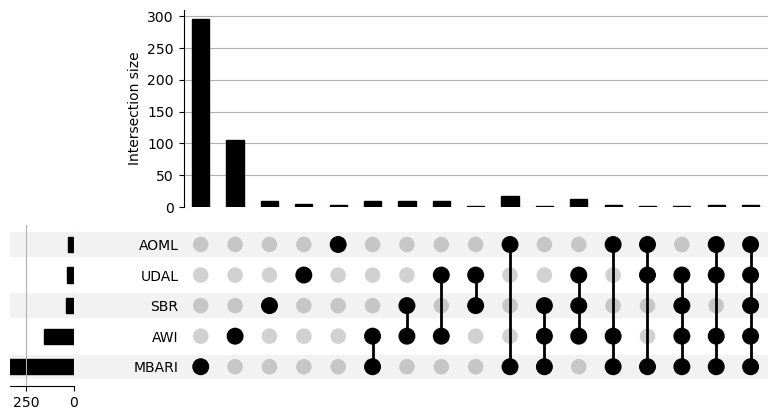

count1
AOML AWI MBARI SBR UDAL        
0    0   1     0   0        295
     1   0     0   0        105
1    0   1     0   0         18
0    1   0     1   1         12
     0   0     1   0         10
     1   0     0   1         10
               1   0         10
         1     0   0          9
     0   0     0   1          5
1    0   0     0   0          3
     1   1     0   0          3
                   1          3
               1   1          3
0    1   1     1   0          1
                   1          1
     0   0     1   1          1
1    0   1     0   1          1

In [72]:
# start with just ASVs in control samples:
df = blastn.copy()
#df = df.drop_duplicates('ASV')
df = df.loc[df['ASV'].isin(asv_list)==True]
df.set_index('ASV', inplace=True)
df = df.join(reads_institute)
df = df.groupby('hit_def').sum(numeric_only=True)
df = df.drop(['bitscore', '%ID', 'total_reads'], axis=1)
df = df.reset_index()
df.loc[df['hit_def'].str.contains('\|'), 'PR2'] = 'PR2'
df = df.sort_values('PR2')
df = df.loc[df['PR2']=='PR2']
df = df.drop('PR2', axis=1)
df.set_index('hit_def', inplace=True)
#df = df.groupby('hit_def').sum(numeric_only=True)
df = df.astype(bool).astype(int)

#df['tot'] = df.sum(axis=1)
#df = df.sort_values('tot', ascending=False)

# get into upset plot format:
df['count1'] = 1
df = df.groupby(['AOML', 'AWI', 'MBARI', 'SBR', 'UDAL']).sum()
df = df.sort_values('count1', ascending=False)
upsetplot.plot(df,sum_over="count1",subset_size="sum")
plt.show()
df

In [17]:
# start with just ASVs in control samples:
df = blastn.copy()
'''print(list(df))
cols = list(df)
df.set_index('ASV', inplace=True)
#df = pd.concat([df, asv_all], axis=1)
df = df.join(asv_all)
df = df.reset_index()
df = df.set_index(cols)
df = df.T
#df = df.join(meta_all)
df
'''


['sequence', 'ASV', 'Analyzing_Institute', 'bitscore', '%ID', 'hit_def', 'total_reads']


sequence            CAATAGCGTATATTAAAGTTGTTGCAGTTAAAAAGCTCGTAGTCGGATTTCGGGTCGGGCCGAGCGGTCTGCCGATGGGTATGCACTGTTTGGCGCGGCCTTCTTTCCGGAGACCGCGGCTACTCTTAACTGAGCGGGCGTGGGAGACGGATCGTTTACTTTGAAAAAATCAGAGTGTTTCTAGCAGGCAGCTCGCTCTTGCATAGGTTAGCATGGGATAATTTAATAGGACTCTGGTGCTATTTTGTTGGTTTCGAACACCGGAGTAATGATTAAAAGGGGCAGTCAGGGGCACTCGTATTCCGTCGAGAGAGGTGAAATTCTCAGACCAATGGAAGACGAACCACTGC  \
ASV                                                                                                                                                                                                                                                                                                                                                                          ASV_1   
Analyzing_Institute                                                                                                                                                                                                                                                                                                                                                           UDAL   
bitscore                                                                                                                                                                                                                                                                                                                                                                     350.0   
%ID                                                                                                                                                                                                                                                                                                                                                                         100.00   
hit_def                                                                                                                                                                                            KC488454.1.1667_U|18S_rRNA|nucleus|clone_HL5aSF04.03|Eukaryota|Haptista|Haptophyta|Haptophyta_X|Prymnesiophyceae|Phaeocystales|Phaeocystaceae|Phaeocystis|Phaeocystis_pouchetii   
total_reads                                                                                                                                                                                                                                                                                                                                                               7011.0     
Davenport_02_0008                                                  0.0                                                                                                                                                                                                                                                                                                               
Davenport_06_0008                                                  0.0                                                                                                                                                                                                                                                                                                               
Davenport_11_0008                                                  0.0                                                                                                                                                                                                                                                                                                               
Davenport_15_0008                                                  0.0                                                                                                                                                                                              

## Plot network

In [2]:
file = '/Users/kpitz/github/GLOMICON/intercomparison/Merged_Datasets/network/blastnall_PR2_mergedhits_95ID_evenmock.csv'
df = pd.read_csv(file)
print(list(df))
df = df[['ASV','hit_def', 'bitscore', '%ID']]
edge_df = df.copy()
edge_df

['sequence', 'ASV', 'Analyzing_Institute', 'bitscore', '%ID', 'hit_def', 'total_reads']


,ASV,hit_def,bitscore,%ID
0,ASV_1,KC488454.1.1667_U|18S_rRNA|nucleus|clone_HL5aS...,350.0,100.00
1,ASV_2,AJ535170.1.1763_U|18S_rRNA|nucleus|clone_p928|...,127.0,100.00
2,ASV_3,KJ961704.1.1788_U|18S_rRNA|nucleus|strain_52|E...,118.0,97.64
3,ASV_4,GU373969.1.1789_U|18S_rRNA|nucleus|strain_CCMP...,127.0,100.00
4,ASV_5,MN965778.1.1765_U|18S_rRNA|nucleus||Eukaryota|...,126.0,100.00
...,...,...,...,...
2031,ASV_14327,ASV_11587,376.0,99.74
2032,ASV_14327,ASV_11383,373.0,99.47
2033,ASV_14327,ASV_10416,373.0,99.47
2034,ASV_14547,ASV_11315,366.0,99.73


In [67]:
df = edge_df.copy()
df = df[['hit_def']]
#df['Analyzing_Institute']
# get things missing
df = df.loc[df['hit_def'].isin(vertices)==False]
df = df.drop_duplicates()
#df = df.sort_values('hit_def')
df.loc[df['hit_def'].str.contains('\|'), 'PR2'] = 'PR2'
df = df.sort_values('PR2')
print(df['hit_def'][0])
df

KC488454.1.1667_U|18S_rRNA|nucleus|clone_HL5aSF04.03|Eukaryota|Haptista|Haptophyta|Haptophyta_X|Prymnesiophyceae|Phaeocystales|Phaeocystaceae|Phaeocystis|Phaeocystis_pouchetii


<>:8: SyntaxWarning: invalid escape sequence '\|'
<>:8: SyntaxWarning: invalid escape sequence '\|'
/var/folders/5v/h4s_0pz17yb6f6krsxkzr5dw000b65/T/ipykernel_80830/1896545000.py:8: SyntaxWarning: invalid escape sequence '\|'
  df.loc[df['hit_def'].str.contains('\|'), 'PR2'] = 'PR2'


,hit_def,PR2
0,KC488454.1.1667_U|18S_rRNA|nucleus|clone_HL5aS...,PR2
509,GU824491.1.1202_U|18S_rRNA|nucleus|clone_AA5F1...,PR2
508,GU819759.1.1204_U|18S_rRNA|nucleus|clone_BCB5F...,PR2
507,AF290539.1.1815_U|18S_rRNA|nucleus|strain_1|Eu...,PR2
506,GU820155.1.1196_U|18S_rRNA|nucleus|clone_A95F1...,PR2
...,...,...
215,KJ763296.1.1794_U|18S_rRNA|nucleus|clone_SGUH7...,PR2
212,KJ763869.1.1797_U|18S_rRNA|nucleus|clone_SGYP7...,PR2
864,KJ763396.1.1803_U|18S_rRNA|nucleus|clone_SGUH9...,PR2
894,ASV_5441,NaN


In [3]:
# vertices df:
file = '/Users/kpitz/github/GLOMICON/intercomparison/Merged_Datasets/network/blastnall_PR2_mergedhits_95ID_evenmock.csv'
df = pd.read_csv(file)
print(list(df))
df = df.drop_duplicates('ASV')
#df.set_index('ASV', inplace=True)
df = df.drop(['bitscore', '%ID', 'sequence', 'hit_def'], axis=1)
vert_df = df.copy()
vertices = df.ASV.tolist()
df

['sequence', 'ASV', 'Analyzing_Institute', 'bitscore', '%ID', 'hit_def', 'total_reads']


,ASV,Analyzing_Institute,total_reads
0,ASV_1,UDAL,7011.0
1,ASV_2,MBARI,44726.0
2,ASV_3,MBARI,39284.0
3,ASV_4,MBARI,101282.0
4,ASV_5,MBARI,87.0
...,...,...,...
1372,ASV_9310,SBR,2.0
1374,ASV_9351,SBR,1.0
1378,ASV_10338,AWI,22.0
1800,ASV_12112,AWI,215.0


In [49]:
g = ig.Graph.DataFrame(
    edges=edge_df,
    vertices=vert_df,
    use_vids = False,
    directed=False # Set to True or False as needed
)
g

ValueError: Some vertices in the edge DataFrame are missing from vertices DataFrame

In [25]:
#g = ig.Graph.TupleList(df.itertuples(index=False), directed=True, weights=True, edge_attrs=["bitscore", "%ID"])
g = ig.Graph.TupleList(df.itertuples(index=False), directed=False, weights=True)
print(g.summary())
g

IGRAPH UNW- 1521 2036 -- 
+ attr: name (v), weight (e)


In [28]:
# The decompose function separates the graph into a list of its connected components
subgraphs = g.decompose() 

# 'subgraphs' is now a list where each element is an igraph Graph object 
# representing a separate interconnected group.
print(f"Decomposed into {len(subgraphs)} subgraphs (connected components).")

# You can access individual subgraphs
first_group = subgraphs[0]
print(f"The first group has {first_group.vcount()} vertices and {first_group.ecount()} edges.")


Decomposed into 518 subgraphs (connected components).
The first group has 19 vertices and 55 edges.


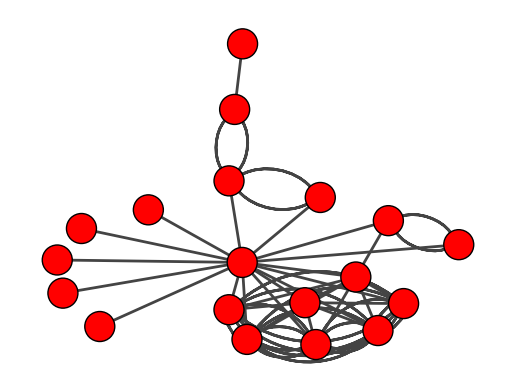

In [31]:
fig, ax = plt.subplots()
ig.plot(first_group, target=ax)

In [32]:
edge_df = first_group.get_edge_dataframe()
edge_df

,source,target,weight
edge ID,,,
0,0,1,350.0
1,0,2,350.0
2,1,2,381.0
3,1,3,340.0
4,4,5,334.0
5,1,6,337.0
6,3,6,347.0
7,3,6,347.0
8,4,6,344.0


In [27]:
g.neighborhood([0, 1], order=2)

[[0,
  1,
  25,
  960,
  1048,
  1062,
  1074,
  1222,
  1262,
  419,
  571,
  746,
  962,
  966,
  993,
  999,
  1269],
 [1,
  0,
  25,
  419,
  571,
  746,
  960,
  962,
  966,
  993,
  999,
  1048,
  1062,
  1074,
  1222,
  1262,
  1269,
  498]]

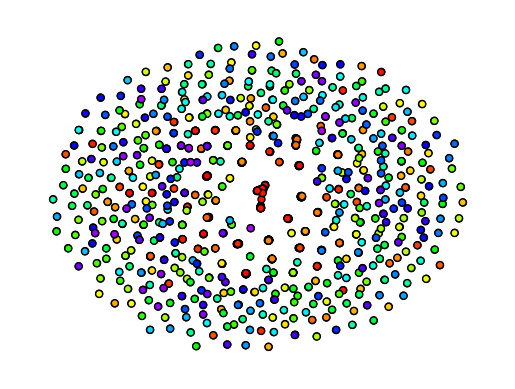

In [26]:
components = g.connected_components(mode="weak")
fig, ax = plt.subplots()
ig.plot(
    components,
    target=ax,
    palette=ig.RainbowPalette(),
    vertex_size=7,
    vertex_color=list(map(int, ig.rescale(components.membership, (0, 200), clamp=True))),
    edge_width=0.7
)
plt.show()

In [5]:

# Use the Graph.DataFrame function
# Specify the columns for source and target, and potentially edge/vertex attributes
# The 'use_vids' parameter can be set if you're using numeric IDs
network_graph = igraph.Graph.DataFrame(edges_df, directed=False)
print(network_graph.summary())

TypeError: Source and target IDs must be 0-based integers, found types [dtype('O'), dtype('O')]

In [18]:
'''mygraph = ig.Graph.DataFrame(df, use_vids = False)
print(mygraph.summary())'''

"mygraph = ig.Graph.DataFrame(df.set_index('ASV'), use_vids = False)\nprint(mygraph.summary())"